In [30]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
from figures_setup import *
from utils import set_color_code

# FOLFIRI treatment of organoids (time course)

## Getting data from arrayExpress: E-MTAB-16836

In [32]:
# Download data from arrayExpress and reassemble anndata object 
from utils_arrayExpress import get_public_study_adata

accession = "E-MTAB-16836"
download_dir = '../data_arrayExpress'
adata = get_public_study_adata(
    accession=accession,
    download_dir=download_dir,
    dataset='LM3'
)
adata

[setup] Download directory: ../data_arrayExpress
[1/3] Found existing files for E-MTAB-16836 in: ../data_arrayExpress/E-MTAB-16836
      force_download=False -> skipping download.
[2/3] Inferring dataset structure in: ../data_arrayExpress/E-MTAB-16836
      Inferred 2 dataset representations:
      - LM2 (full prefix: Org_chemo_LM2)
      - LM3 (full prefix: Org_chemo_LM3)
      Selected dataset for in-memory loading: LM3 (full prefix: Org_chemo_LM3)
[3/3] Multiple datasets detected.
      Saving all inferred datasets to disk; loading only one into memory.
      Already exists, skipping rebuild: E-MTAB-16836/E-MTAB-16836_LM2.h5ad
      Already exists, skipping rebuild: E-MTAB-16836/E-MTAB-16836_LM3.h5ad
      Loading selected dataset from disk: E-MTAB-16836/E-MTAB-16836_LM3.h5ad


AnnData object with n_obs × n_vars = 1173 × 29483
    obs: 'sample_id', 'Timepoint', 'leiden', 'HTO_classification', 'HTO_classification.global', 'HTO_maxID', 'MUNOZ_LGR5_SIGNATURE_UCell', 'Lgr5_signature_UCell', 'Wnt_ON_signature_UCell', 'YAP_22_UCell', 'Fetal_Mustata_UCell', 'coreHRC_UCell'
    uns: 'dataset_prefix', 'source_files', 'loaded_from_h5ad'
    obsm: 'X_umap'
    layers: 'counts', 'log1p'

## TEMP: data fix

Currently, wrong leiden clustering on arrayExpress. Re-do with correct resolution...

In [33]:
### Read leiden clustering from new file
obs_file = '../data/Org_chemo_LM3_metadata.txt'
obs = pd.read_csv(obs_file, sep='\t', index_col=0)
obs.head()

,sample_id,Timepoint,leiden,HTO_classification,HTO_classification.global,HTO_maxID,MUNOZ_LGR5_SIGNATURE_UCell,Lgr5_signature_UCell,Wnt_ON_signature_UCell,YAP_22_UCell,Fetal_Mustata_UCell,coreHRC_UCell
barcode,,,,,,,,,,,,
AAACGAAAGGTTGGTG-1_2,LM3,0,3,HD4347-LM3-0h,Singlet,HD4347-LM3-0h,0.019235,0.128457,0.077940,0.000000,0.063719,0.024787
AAACGAACAGTAGTGG-1_2,LM3,12,1,HD4347-LM3-12h,Singlet,HD4347-LM3-12h,0.037987,0.277822,0.094185,0.000000,0.052176,0.000000
AAACGCTCAATTCGTG-1_2,LM3,48,0,HD4347-LM3-48h,Singlet,HD4347-LM3-48h,0.027014,0.092118,0.075790,0.000000,0.082643,0.093776
AAACGCTCAGACGCTC-1_2,LM3,84,1,HD4347-LM3-72h+12h,Singlet,HD4347-LM3-72h+12h,0.023236,0.000000,0.083069,0.006672,0.059193,0.022506
AAACGCTGTATCGTGT-1_2,LM3,72,0,HD4347-LM3-72h,Singlet,HD4347-LM3-72h,0.040180,0.000000,0.064873,0.018093,0.070015,0.019752


In [34]:
# Add leiden to adata.obs
leiden_key = 'leiden'
assert set(obs.index) == set(adata.obs.index), "Index of obs does not match adata.obs"
adata.obs[leiden_key] = obs['leiden']
# make sure leiden is categorical
adata.obs[leiden_key] = pd.Categorical(adata.obs[leiden_key])
print(adata.obs.head(2))

                     sample_id  Timepoint leiden HTO_classification  \
AAACGAAAGGTTGGTG-1_2       LM3          0      3      HD4347-LM3-0h   
AAACGAACAGTAGTGG-1_2       LM3         12      1     HD4347-LM3-12h   

                     HTO_classification.global       HTO_maxID  \
AAACGAAAGGTTGGTG-1_2                   Singlet   HD4347-LM3-0h   
AAACGAACAGTAGTGG-1_2                   Singlet  HD4347-LM3-12h   

                      MUNOZ_LGR5_SIGNATURE_UCell  Lgr5_signature_UCell  \
AAACGAAAGGTTGGTG-1_2                    0.019235              0.128457   
AAACGAACAGTAGTGG-1_2                    0.037987              0.277822   

                      Wnt_ON_signature_UCell  YAP_22_UCell  \
AAACGAAAGGTTGGTG-1_2                0.077940           0.0   
AAACGAACAGTAGTGG-1_2                0.094185           0.0   

                      Fetal_Mustata_UCell  coreHRC_UCell  
AAACGAAAGGTTGGTG-1_2             0.063719       0.024787  
AAACGAACAGTAGTGG-1_2             0.052176       0.000000  


In [35]:
# Add obs columns not in adata.obs
for col in obs.columns:
    if col not in adata.obs.columns:
        adata.obs[col] = obs[col]

del obs

#### Currently wrong log1p counts layer on arrayExpress. Re-do with correct log1p layer

In [36]:
# Check exported matrix in git repo: counts_log1p export in git repo identical to original analysis path.
log1p = pd.read_csv('../data/Org_chemo_LM3_counts_log1p.txt', index_col=0, sep = '\t')
adata.layers['log1p'] = log1p.T.values

## UMAP representation

In [37]:
# Add time annotation
import utils
import utils_chemo_timecourse as utils_spec
from utils_chemo_timecourse import color_code

utils_spec.add_time(adata)
utils.set_uns_colors(adata, color_code, 'time')

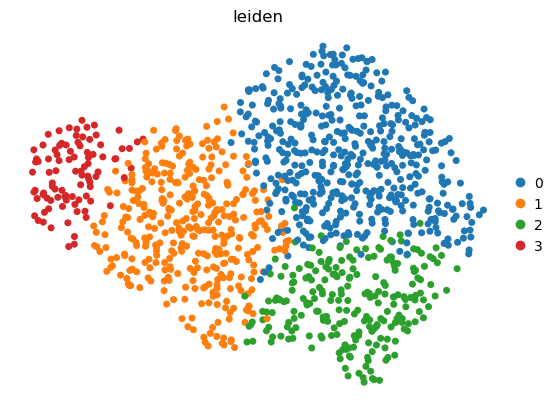

In [38]:
# Annotation UMAP
sc.pl.umap(adata, color=[leiden_key], frameon=False, title=None)

/tmp/ipykernel_3539631/3401910890.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  freq = adata.obs.pivot_table(index='time', columns=leiden_key,


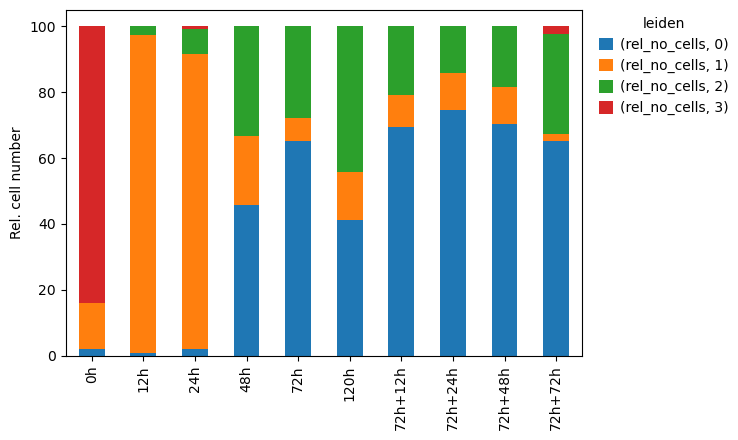

In [39]:
# Get cluster composition
cell_bc = 'cell_bc'
if cell_bc not in adata.obs.columns:
    adata.obs[cell_bc] = adata.obs.index
freq = adata.obs.pivot_table(index='time', columns=leiden_key, 
                             values=[cell_bc], aggfunc={cell_bc: 'count'})
# Rename columns
cell_count_label = 'no_cells'
colnames = {cell_bc: cell_count_label,}
freq.rename(columns=colnames, inplace=True)

# Normalize data and write to new object
freq_rel = freq.div(freq.sum(axis=1), axis=0)*100
# Rename columns
cell_count_label = 'rel_no_cells'
colnames = {'no_cells': cell_count_label,}
freq_rel.rename(columns=colnames, inplace=True)

# Stacked bar plot
fig, ax = plt.subplots(figsize=(7.5, 4.5))
freq_rel.plot(
    kind='bar', 
    stacked=True, 
    ax=ax, 
    color=adata.uns[f'{leiden_key}_colors'][:freq_rel.shape[1]]
)

ax.set_ylabel('Rel. cell number')
ax.set_xlabel('')
ax.legend(title=leiden_key, bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [40]:
freq_rel.to_csv(f'../data_suppl/{accession}_Ext_Fig_10j.csv')
freq_rel

rel_no_cells                                 
leiden             0          1          2          3
time                                                 
0h          1.869159  14.018692   0.000000  84.112150
12h         0.636943  96.815287   2.547771   0.000000
24h         1.834862  89.908257   7.339450   0.917431
48h        45.893720  20.772947  33.333333   0.000000
72h        65.217391   7.065217  27.717391   0.000000
120h       41.176471  14.705882  44.117647   0.000000
72h+12h    69.444444   9.722222  20.833333   0.000000
72h+24h    74.725275  10.989011  14.285714   0.000000
72h+48h    70.370370  11.111111  18.518519   0.000000
72h+72h    65.116279   2.325581  30.232558   2.325581

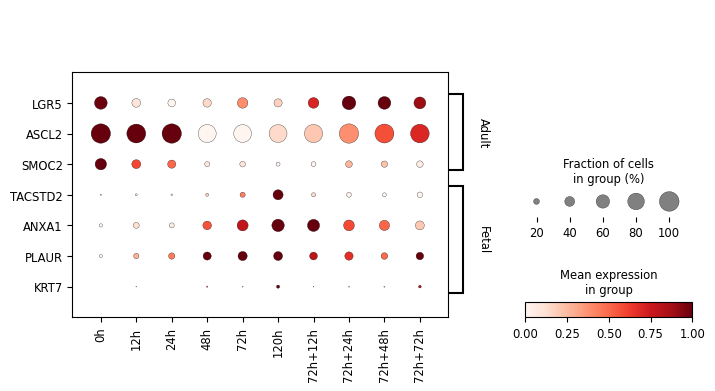

In [43]:
# Make dotplot over feature
marker_genes_dict = {
    "Adult": ["LGR5", "ASCL2", 'SMOC2'],
    "Fetal": ["TACSTD2", "ANXA1", "PLAUR", "KRT7"],
}

fig, ax = plt.subplots(figsize=(8,4))
sc.pl.dotplot(adata,
                marker_genes_dict,
                groupby='time',
                layer='log1p',
                standard_scale='var',
                swap_axes=True,
                ax=ax,
            )
fig.tight_layout()
fig.show()

/tmp/ipykernel_3539631/2951159676.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


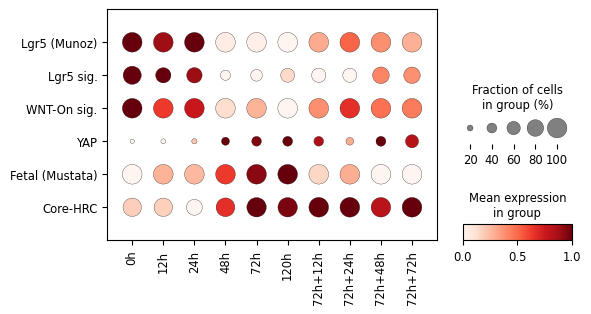

In [29]:
# Make dotplot over feature
feature = "time"

marker_genesets = {
    "MUNOZ_LGR5_SIGNATURE_UCell": ["Lgr5 (Munoz)"],
    "Lgr5_signature_UCell": ["Lgr5 sig."],
    "Wnt_ON_signature_UCell": ["WNT-On sig."],
    "YAP_22_UCell": ["YAP"],
    "Fetal_Mustata_UCell": ["Fetal (Mustata)"],
    "coreHRC_UCell": ["Core-HRC"],
}

genes = list(marker_genesets.keys())
labels = [marker_genesets[g][0] for g in genes]

dp = sc.pl.dotplot(
    adata,
    genes,
    groupby=feature,
    standard_scale="var",
    swap_axes=True,
    show=False,
    figsize=(6, 3),
)
# increase space between y-axis items

ax = dp["mainplot_ax"]
ax.set_yticklabels(labels)

plt.tight_layout()
plt.show()

## DGEA cluster 0 vs cluster 2 with gene set enrichment

In [14]:
# Import gene sets
print("Writing gene set details into anndata object...")
adata = utils.get_gene_sets(adata, verbose=False)

# Get gene sets from anndata object
net = adata.uns['gene_sets']

Writing gene set details into anndata object...


In [15]:
# Perform network check
import utils_genelist as genelist
net = genelist.pre_network_checks(
    net = net, 
    var_names = adata.var_names, 
    source='gene_set', 
    target='gene', 
    weight='weight',
)

/omics/groups/OE0285/internal/puschhof/github_projects/TROP2_in_CRC/figures/utils_genelist.py:715: UserWarning: Skipping score_Mex3a_Barriga (less than 5 overlapping genes)
  warnings.warn(f"Skipping {geneset} (less than 5 overlapping genes)")


In [16]:
# Differential gene expression analysis across clusters 2 and 0
adata.obs[leiden_key] = adata.obs[leiden_key].astype(str).astype("category")

sc.tl.rank_genes_groups( # requires character levels
    adata,
    groupby=leiden_key,
    groups=['2'],
    reference='0',
    pts=True,
    use_raw=False,
    layer="log1p",
    method="wilcoxon",
    corr_method="benjamini-hochberg",
)
df_dgea = sc.get.rank_genes_groups_df(adata, group='2') #or group=None

In [17]:
df_dgea.head(10)

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group
0,PHLDA2,13.471537,1.430688,2.300273e-41,3.390947e-37,0.991228
1,MAP1LC3B,11.749967,0.980577,7.064697e-32,2.603606e-28,0.986842
2,PPP1R15A,11.343821,1.292468,7.959220e-30,2.133288e-26,0.964912
3,SAT1,11.186627,1.024971,4.741246e-29,1.075278e-25,0.995614
4,TNFRSF12A,10.886374,1.249630,1.338645e-27,2.819090e-24,0.986842
5,SDCBP,10.832750,1.043114,2.408115e-27,4.733231e-24,0.960526
6,S100A6,10.800615,1.036682,3.419060e-27,5.929656e-24,1.000000
7,MARCKS,10.770415,0.888447,4.748543e-27,7.777849e-24,1.000000
8,H3F3B,10.459515,0.536021,1.325332e-25,1.953739e-22,1.000000
9,KLF6,10.255860,1.836618,1.113793e-24,1.427738e-21,0.798246


In [18]:
def get_anndata_from_file(data_path=None, filename=None,
                          df=None,
                          stat_key='stat',
                          feature_key='names'):
    """
    Read anndata object from file.
    
    Args:
        data_path: path to data file
        filename: name of data file
        
    Returns:
        adata: anndata object
    """

    # Test if input data is provided
    if df is None and not os.path.exists(os.path.join(data_path, filename)):
        raise ValueError("Input data not correctly defined. Provide dataframe or input file.")

    # Read data from file if required
    if df is None:
        if not os.path.exists(os.path.join(data_path, filename)):
            raise ValueError(f"File not found: {filename}")
        if filename.endswith(".h5ad"):
            adata = sc.read_h5ad(os.path.join(data_path, filename))
            if adata.raw is None:
                if 'normalized' in adata.layers.keys():
                    print("Set raw to normalized")
                    adata.raw = adata.layers['normalized'].copy()
        elif filename.endswith(".pkl"):
            df = pd.read_pickle(os.path.join(data_path, filename))
            # Convert to Anndata object
            adata = anndata.AnnData(df)
            adata.obs['contrast'] = df.index  # Adds the comparison labels as metadata in obs
            adata.var_names = df.T.index
            adata.raw = adata
        elif filename.endswith(".csv"):
            df = pd.read_csv(os.path.join(data_path, filename))
            # Rename columns if applicable
            if stat_key not in df.columns and 'scores' in df.columns:
                print(f"Rename column 'scores' to {stat_key}")
                df.rename(columns={'scores': stat_key}, inplace=True)
        else:
            raise ValueError(f"File format not implemented: {filename}")

    ### Construct adata from DGEA result if needed
    print('Construct adata from DGEA results')
    if 'contrast' not in df.columns:
        if 'group' in df.columns:
            df['contrast'] = [f"{g}-vs-rest" for g in df['group']]
        else:
            df['contrast'] = 'test_vs_ref'
    elif 'group' in df.columns:
        df['contrast'] = [f"{g}-vs-all" for g in df['group']]
        
    # Turn into score matrix
    df_pivot = df.pivot(index='contrast', columns=feature_key, values=stat_key)
    adata = anndata.AnnData(
        X=df_pivot.values,
        obs=pd.DataFrame(index=df_pivot.index),
        var=pd.DataFrame(index=df_pivot.columns),
    )

    # Set nan to zero
    adata.X[np.isnan(adata.X)] = 0

    adata.raw = adata

    return adata

# Get anndata object from DGEA results
ad_dgea = get_anndata_from_file(
    df=df_dgea,
    stat_key = 'scores', 
    feature_key = 'names'
)

Construct adata from DGEA results


In [19]:
# Run enrichment method ULM
import decoupler as dc
dc.mt.ulm(
    data = ad_dgea,
    net = net,
)

# Get activities from anndata
acts = dc.pp.get_obsm(ad_dgea, key='score_ulm')

In [20]:
# Get df from enrichment results
def get_enrichment_from_adata(acts, contrast = 'contrast', name = 'source'):
        
    ''' Turn anndata object acts into pandas DataFrame with activities and p-values.'''

    # Create data frame from acts.obsm['estimate']
    act_df = pd.DataFrame(acts.X, columns=acts.var_names, index=acts.obs_names)   
    act_df = act_df.reset_index().melt(id_vars=contrast, var_name='source', value_name='acts')

    # Create data frame from acts.obsm['padj']
    key = [key for key in acts.obsm.keys() if key.startswith('padj')][0]
    pval_df = pd.DataFrame(acts.obsm[key].values, columns=acts.var_names, index=acts.obs_names)
    pval_df = pval_df.reset_index().melt(id_vars=contrast, var_name='source', value_name='padj')

    # Merge df and pval_df
    df = pd.merge(act_df, pval_df, on=[contrast, name])
    return df

# Get enrichment results in df format
df = get_enrichment_from_adata(acts, contrast = 'contrast', name = 'source') # To save to disk
df = df.sort_values(by='acts', ascending=False)
df.head(2)

,contrast,source,acts,padj
18,test_vs_ref,score_allHR,24.061540,5.536957e-125
26,test_vs_ref,score_tmeHR,23.656034,3.572244e-121


In [21]:
# Change to publication names ### To be added
from utils_chemo_timecourse import gs_names_for_pub
df['source'] = df['source'].map(gs_names_for_pub)
# Add contrast specifics
df['contrast'] = 'Cluster 2 vs Cluster 0'
df.sort_values(by='acts', ascending=False, inplace=True, ignore_index=True)
df.to_csv('../data_suppl/Ext_Fig_10k_ulm.csv', index=False)

In [22]:
# Filter by significant results
df_sign = df[df['padj'] < 0.05]
df_sign

,contrast,source,acts,padj
0,Cluster 2 vs Cluster 0,All-HRC,24.061540,5.536957e-125
1,Cluster 2 vs Cluster 0,TME-HRC,23.656034,3.572244e-121
2,Cluster 2 vs Cluster 0,YAP,16.881772,1.294183e-62
3,Cluster 2 vs Cluster 0,Core-HRC,11.300494,8.380793e-29
4,Cluster 2 vs Cluster 0,LGR5+ MEX3A+,10.764736,2.622495e-26
5,Cluster 2 vs Cluster 0,NaN,5.504055,9.204152e-08
6,Cluster 2 vs Cluster 0,Fetal,5.340763,2.101631e-07
7,Cluster 2 vs Cluster 0,Epi-HRC,3.793419,3.093677e-04
8,Cluster 2 vs Cluster 0,NaN,3.577132,6.712853e-04
9,Cluster 2 vs Cluster 0,Neuroendocrine,3.274477,1.788905e-03


<Figure size 300x600 with 0 Axes>

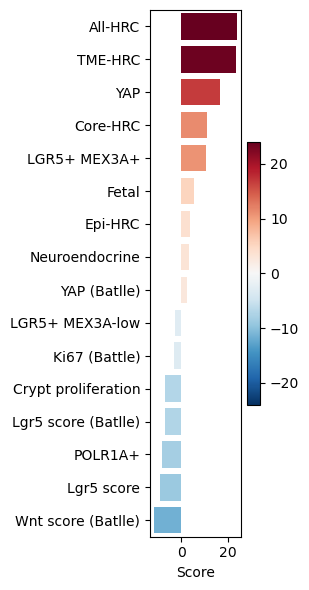

In [23]:
# Make bar plot of activities
padj_thres = 0.05

# Filter by significance
df_plot = df_sign[df_sign['padj'] < padj_thres]

# Restructure for plotting
contrast = 'test_vs_ref'
df_plot.rename(columns={'acts': contrast}, inplace=True)
df_plot = df_plot.drop(columns=['padj', 'contrast'])
df_plot.set_index('source', inplace=True)
df_plot = df_plot.T

# Extract maximum color range
act_min = df_plot.min().min()
act_max = df_plot.max().max()
vmax = max(abs(act_min), abs(act_max))

# Extract figure size
height = 6
width = 3
figsize = (width, height)

# Set up plot
plt.figure(figsize=figsize)
fig = dc.pl.barplot(
    data=df_plot, 
    name=contrast,
    vmin=-vmax,
    vmax=vmax,
    vcenter=0,
    return_fig=True
)
# Get the Axes from the Figure
fig.set_size_inches(figsize)
ax = fig.axes[0]
ax.set_title(f'{contrast}')
ax.set_xlabel('Score')
ax.set_ylabel('')
legend = ax.get_legend()
ax.set_title('')
fig.tight_layout()
plt.show()

# Session info

The analysis above has been performed using a micromamba environment with the following package versions:

In [24]:
session_info.show()

/omics/groups/OE0285/internal/puschhof/envs/env_funcomics/lib/python3.10/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)
